**📗 EDA & Thống kê cơ bản — Bộ ĐẦY ĐỦ (rideshare_kaggle.csv)**
**Bộ gốc đầy đủ từ Kaggle: ~693.000 chuyến, còn loại Taxi (thiếu giá).**

⏳ File 350 MB — nạp mất ~30–60 giây và tốn ~2 GB RAM. Dùng bộ này khi cần kết luận chắc chắn (nhiều mẫu surge gấp ~10 lần).

Nội dung: thống kê cơ bản → từ điển trường dữ liệu → chất lượng dữ liệu → phân bố → tương quan → độ phủ thời gian.

> ▶️ Bấm **Run All** để chạy toàn bộ.


**1. Nạp dữ liệu**

In [1]:
# ===== CAU HINH =====
CSV_NAME = "rideshare_kaggle.csv"   # doi sang "uber_lyft.csv" neu muon

from pathlib import Path
_cands = [Path("../data")/CSV_NAME, Path("data")/CSV_NAME, Path(CSV_NAME)]
CSV_PATH = next((str(p) for p in _cands if p.exists()), None)
if CSV_PATH is None: raise FileNotFoundError(f"Khong tim thay {CSV_NAME} trong data/")
print("Doc du lieu tu:", CSV_PATH)

%matplotlib inline
import math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 200)

BLUE, ORANGE, GREEN, RED, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#666666"
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,
    "axes.spines.right":False,"axes.grid":True,"grid.color":"#ECECEC","font.size":10})

df_raw = pd.read_csv(CSV_PATH)
print("Kich thuoc GOC:", df_raw.shape[0], "dong x", df_raw.shape[1], "cot")
print("Bo nho:", round(df_raw.memory_usage(deep=True).sum()/1048576, 1), "MB")
df_raw.head(3)

Doc du lieu tu: ..\data\rideshare_kaggle.csv
Kich thuoc GOC: 693071 dong x 57 cot
Bo nho: 783.2 MB


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,product_id,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,long_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,windGustTime,visibility,temperatureHigh,temperatureHighTime,temperatureLow,temperatureLowTime,apparentTemperatureHigh,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureLowTime,icon,dewPoint,pressure,windBearing,cloudCover,uvIndex,visibility.1,ozone,sunriseTime,sunsetTime,moonPhase,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,lyft_line,Shared,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,Mostly Cloudy,Rain throughout the day.,0.0000,0.0,0.68,8.66,9.17,1545015600,10.000,43.68,1544968800,34.19,1545048000,37.95,1544968800,27.39,1545044400,partly-cloudy-night,32.70,1021.98,57,0.72,0,10.000,303.8,1544962084,1544994864,0.30,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,lyft_premier,Lux,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,Rain,"Rain until morning, starting again in the eve...",0.1299,1.0,0.94,11.98,11.98,1543291200,4.786,47.30,1543251600,42.10,1543298400,43.92,1543251600,36.20,1543291200,rain,41.83,1003.97,90,1.00,0,4.786,291.1,1543232969,1543266992,0.64,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,lyft,Lyft,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,Clear,Light rain in the morning.,0.0000,0.0,0.75,7.33,7.33,1543334400,10.000,47.55,1543320000,33.10,1543402800,44.12,1543320000,29.11,1543392000,clear-night,31.10,992.28,240,0.03,0,10.000,315.7,1543319437,1543353364,0.68,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000


**2. Làm sạch & tạo biến dẫn xuất**

In [2]:
df = df_raw.copy()
# Doi ten 2 cot mat header (chi co o uber_lyft.csv)
df = df.rename(columns={"Unnamed: 55":"apparentTemperatureMax",
                        "Unnamed: 56":"apparentTemperatureMaxTime"})
n_start = len(df)
# timestamp dang khoa hoc -> ep ve so
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
n_bad_ts = df["timestamp"].isna().sum()
df = df.dropna(subset=["timestamp"])
df["utc"]   = pd.to_datetime(df["timestamp"], unit="s")
df = df[df["utc"] < "2019-01-01"]
df["local"] = df["utc"] - pd.Timedelta(hours=5)      # Boston EST = UTC-5

n_no_price = df["price"].isna().sum()
df = df.dropna(subset=["price"])

for c in ["short_summary","long_summary","icon"]:
    if c in df.columns: df[c] = df[c].astype(str).str.strip()

df["hour_local"]     = df["local"].dt.hour
df["weekday_local"]  = df["local"].dt.weekday
df["date_local"]     = df["local"].dt.normalize()
df["price_per_mile"] = np.where(df["distance"]>0, df["price"]/df["distance"], np.nan)
df["is_surge"]       = (df["surge_multiplier"]>1).astype(int)

print(f"Dong ban dau        : {n_start:,}")
print(f"  - timestamp loi   : {n_bad_ts:,}")
print(f"  - thieu gia (price): {n_no_price:,}")
print(f"Con lai sau lam sach: {len(df):,}")

Dong ban dau        : 693,071
  - timestamp loi   : 0
  - thieu gia (price): 55,095
Con lai sau lam sach: 637,976


**3. Thống kê cơ bản**

In [3]:
print("="*60); print("THONG KE CO BAN"); print("="*60)
print(f"So chuyen (sau lam sach) : {len(df):,}")
print(f"So truong du lieu        : {df.shape[1]}")
print(f"Khoang thoi gian         : {df.local.min()}  ->  {df.local.max()}")
print(f"So ngay co du lieu       : {df.date_local.nunique()}")
print(f"So khu vuc (source)      : {df.source.nunique()}")
print(f"So loai dich vu (name)   : {df.name.nunique()}")
print(f"So hang (cab_type)       : {df.cab_type.nunique()}  -> {list(df.cab_type.unique())}")
print()
print(f"Gia   : min={df.price.min():.2f}  max={df.price.max():.2f}  "
      f"mean={df.price.mean():.2f}  median={df.price.median():.2f}")
print(f"Q.duong: min={df.distance.min():.2f}  max={df.distance.max():.2f}  "
      f"mean={df.distance.mean():.2f}")
print(f"Ty le co surge: {df.is_surge.mean()*100:.2f}%")

THONG KE CO BAN
So chuyen (sau lam sach) : 637,976
So truong du lieu        : 64
Khoang thoi gian         : 2018-11-25 22:40:46  ->  2018-12-18 14:15:11
So ngay co du lieu       : 18
So khu vuc (source)      : 12
So loai dich vu (name)   : 12
So hang (cab_type)       : 2  -> ['Lyft', 'Uber']

Gia   : min=2.50  max=97.50  mean=16.55  median=13.50
Q.duong: min=0.02  max=7.86  mean=2.19
Ty le co surge: 3.29%


In [4]:
# Thong ke mo ta cac cot so trong tam
KEY = ["price","distance","surge_multiplier","price_per_mile","hour_local",
       "temperature","precipProbability","humidity","windSpeed","visibility"]
KEY = [c for c in KEY if c in df.columns]
df[KEY].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
price,637976.0,16.545,9.324,2.500,9.000,13.500,22.500,97.50
distance,637976.0,2.189,1.135,0.020,1.270,2.160,2.930,7.86
surge_multiplier,637976.0,1.015,0.095,1.000,1.000,1.000,1.000,3.00
price_per_mile,637976.0,9.688,13.706,0.557,4.661,7.492,11.538,1375.00
hour_local,637976.0,11.665,6.799,0.000,6.000,12.000,18.000,23.00
temperature,637976.0,39.582,6.726,18.910,36.450,40.490,43.580,57.22
precipProbability,637976.0,0.146,0.329,0.000,0.000,0.000,0.000,1.00
humidity,637976.0,0.741,0.139,0.380,0.640,0.710,0.880,0.96
windSpeed,637976.0,6.187,3.148,0.450,3.410,5.910,8.410,15.00
visibility,637976.0,8.469,2.602,0.717,8.432,9.880,9.996,10.00


**4. Từ điển trường dữ liệu**

In [5]:
MEANING = {
 "id":("Định danh","Mã duy nhất của mỗi lần báo giá"),
 "timestamp":("Định danh","Thời điểm dạng Unix epoch (giây)"),
 "hour":("Thời gian","Giờ trong ngày (gốc)"),
 "day":("Thời gian","Ngày trong tháng"),
 "month":("Thời gian","Tháng"),
 "datetime":("Thời gian","Thời điểm dạng đọc được"),
 "timezone":("Thời gian","Múi giờ (America/New_York)"),
 "source":("Hành trình","Điểm đón (1 trong 12 khu vực Boston)"),
 "destination":("Hành trình","Điểm đến"),
 "distance":("Hành trình","Khoảng cách chuyến (dặm)"),
 "latitude":("Hành trình","Vĩ độ điểm đón"),
 "longitude":("Hành trình","Kinh độ điểm đón"),
 "cab_type":("Dịch vụ & Giá","Hãng: Uber hoặc Lyft"),
 "product_id":("Dịch vụ & Giá","Mã sản phẩm nội bộ"),
 "name":("Dịch vụ & Giá","Loại dịch vụ (UberX, Black, Lux…)"),
 "price":("Dịch vụ & Giá","★ GIÁ CƯỚC (USD)"),
 "surge_multiplier":("Dịch vụ & Giá","★ Hệ số nhân tăng giá"),
 "temperature":("Thời tiết","Nhiệt độ (°F)"),
 "apparentTemperature":("Thời tiết","Nhiệt độ cảm nhận (°F)"),
 "short_summary":("Thời tiết","Mô tả thời tiết ngắn"),
 "long_summary":("Thời tiết","Mô tả thời tiết dài"),
 "precipIntensity":("Thời tiết","Cường độ mưa"),
 "precipProbability":("Thời tiết","Xác suất mưa (0–1)"),
 "humidity":("Thời tiết","Độ ẩm (0–1)"),
 "windSpeed":("Thời tiết","Tốc độ gió"),
 "windGust":("Thời tiết","Tốc độ gió giật"),
 "windGustTime":("Thời tiết","Thời điểm gió giật (Unix)"),
 "visibility":("Thời tiết","Tầm nhìn xa"),
 "visibility.1":("Thời tiết","⚠️ TRÙNG LẶP với visibility"),
 "icon":("Thời tiết","Biểu tượng thời tiết"),
 "dewPoint":("Thời tiết","Điểm sương"),
 "pressure":("Thời tiết","Áp suất khí quyển"),
 "windBearing":("Thời tiết","Hướng gió (độ)"),
 "cloudCover":("Thời tiết","Độ che phủ mây (0–1)"),
 "uvIndex":("Thời tiết","Chỉ số tia UV"),
 "ozone":("Thời tiết","Nồng độ ozone"),
 "temperatureHigh":("Thời tiết ngày","Nhiệt độ cao nhất trong ngày"),
 "temperatureHighTime":("Thời tiết ngày","Thời điểm nhiệt độ cao nhất"),
 "temperatureLow":("Thời tiết ngày","Nhiệt độ thấp nhất trong ngày"),
 "temperatureLowTime":("Thời tiết ngày","Thời điểm nhiệt độ thấp nhất"),
 "apparentTemperatureHigh":("Thời tiết ngày","Cảm nhận cao nhất"),
 "apparentTemperatureHighTime":("Thời tiết ngày","Thời điểm cảm nhận cao nhất"),
 "apparentTemperatureLow":("Thời tiết ngày","Cảm nhận thấp nhất"),
 "apparentTemperatureLowTime":("Thời tiết ngày","Thời điểm cảm nhận thấp nhất"),
 "temperatureMin":("Thời tiết ngày","Nhiệt độ min"),
 "temperatureMinTime":("Thời tiết ngày","Thời điểm nhiệt độ min"),
 "temperatureMax":("Thời tiết ngày","Nhiệt độ max"),
 "temperatureMaxTime":("Thời tiết ngày","Thời điểm nhiệt độ max"),
 "apparentTemperatureMin":("Thời tiết ngày","Cảm nhận min"),
 "apparentTemperatureMinTime":("Thời tiết ngày","Thời điểm cảm nhận min"),
 "apparentTemperatureMax":("Thời tiết ngày","Cảm nhận max"),
 "apparentTemperatureMaxTime":("Thời tiết ngày","Thời điểm cảm nhận max"),
 "precipIntensityMax":("Thời tiết ngày","Cường độ mưa lớn nhất trong ngày"),
 "uvIndexTime":("Thời tiết ngày","Thời điểm UV đỉnh"),
 "sunriseTime":("Thiên văn","Giờ mặt trời mọc"),
 "sunsetTime":("Thiên văn","Giờ mặt trời lặn"),
 "moonPhase":("Thiên văn","Pha mặt trăng (0–1)"),
 "utc":("[Tự tạo]","Thời điểm UTC"),
 "local":("[Tự tạo]","Thời điểm giờ Boston (UTC-5)"),
 "hour_local":("[Tự tạo]","Giờ địa phương (0–23)"),
 "weekday_local":("[Tự tạo]","Thứ trong tuần (0=T2…6=CN)"),
 "date_local":("[Tự tạo]","Ngày (giờ địa phương)"),
 "price_per_mile":("[Tự tạo]","Giá mỗi dặm = price/distance"),
 "is_surge":("[Tự tạo]","1 nếu surge_multiplier > 1"),
}

rows=[]
for c in df.columns:
    grp, mean_ = MEANING.get(c, ("(khác)","—"))
    ex = df[c].dropna().iloc[0] if df[c].notna().any() else ""
    rows.append({"Trường":c,"Nhóm":grp,"Ý nghĩa":mean_,"Kiểu":str(df[c].dtype),
                 "%Thiếu":round(df[c].isna().mean()*100,1),
                 "Số g.trị":df[c].nunique(),"Ví dụ":str(ex)[:24]})
dict_df = pd.DataFrame(rows)

# --- Hien thi DAY DU, khong rut gon ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 60)

# Thu tu nhom cho de doc
ORDER = ["Định danh","Thời gian","Hành trình","Dịch vụ & Giá",
         "Thời tiết","Thời tiết ngày","Thiên văn","[Tự tạo]","(khác)"]
dict_df["_o"] = dict_df["Nhóm"].apply(lambda g: ORDER.index(g) if g in ORDER else 99)
dict_df = dict_df.sort_values(["_o","Trường"]).drop(columns="_o").reset_index(drop=True)

print(f"TONG CONG: {len(dict_df)} truong, chia thanh {dict_df['Nhóm'].nunique()} nhom")
dict_df["Nhóm"].value_counts().reindex(
    [g for g in ORDER if g in set(dict_df["Nhóm"])]).to_frame("Số trường")


TONG CONG: 64 truong, chia thanh 8 nhom


,Số trường
Nhóm,
Định danh,2
Thời gian,5
Hành trình,5
Dịch vụ & Giá,5
Thời tiết,19
Thời tiết ngày,18
Thiên văn,3
[Tự tạo],7


In [6]:
# ===== HIEN THI TUNG NHOM RIENG =====
for g in [x for x in ORDER if x in set(dict_df["Nhóm"])]:
    sub = dict_df[dict_df["Nhóm"]==g].drop(columns="Nhóm").reset_index(drop=True)
    print()
    print("="*95)
    print(f"  NHÓM: {g}   —   {len(sub)} trường")
    print("="*95)
    display(sub)



  NHÓM: Định danh   —   2 trường


,Trường,Ý nghĩa,Kiểu,%Thiếu,Số g.trị,Ví dụ
0,id,Mã duy nhất của mỗi lần báo giá,object,0.0,637976,424553bb-7174-41ea-aeb4-
1,timestamp,Thời điểm dạng Unix epoch (giây),float64,0.0,35796,1544952607.89



  NHÓM: Thời gian   —   5 trường


,Trường,Ý nghĩa,Kiểu,%Thiếu,Số g.trị,Ví dụ
0,datetime,Thời điểm dạng đọc được,object,0.0,31350,2018-12-16 09:30:07
1,day,Ngày trong tháng,int64,0.0,17,16
2,hour,Giờ trong ngày (gốc),int64,0.0,24,9
3,month,Tháng,int64,0.0,2,12
4,timezone,Múi giờ (America/New_York),object,0.0,1,America/New_York



  NHÓM: Hành trình   —   5 trường


...

,Trường,Ý nghĩa,Kiểu,%Thiếu,Số g.trị,Ví dụ
0,apparentTemperatureHigh,Cảm nhận cao nhất,float64,0.0,124,37.95
1,apparentTemperatureHighTime,Thời điểm cảm nhận cao nhất,int64,0.0,27,1544968800
2,apparentTemperatureLow,Cảm nhận thấp nhất,float64,0.0,136,27.39
3,apparentTemperatureLowTime,Thời điểm cảm nhận thấp nhất,int64,0.0,32,1545044400
4,apparentTemperatureMax,Cảm nhận max,float64,0.0,125,38.07
5,apparentTemperatureMaxTime,Thời điểm cảm nhận max,int64,0.0,27,1544958000
6,apparentTemperatureMin,Cảm nhận min,float64,0.0,137,33.73
7,apparentTemperatureMinTime,Thời điểm cảm nhận min,int64,0.0,29,1545012000
8,precipIntensityMax,Cường độ mưa lớn nhất trong ngày,float64,0.0,65,0.1276
9,temperatureHigh,Nhiệt độ cao nhất trong ngày,float64,0.0,129,43.68



  NHÓM: Thiên văn   —   3 trường


,Trường,Ý nghĩa,Kiểu,%Thiếu,Số g.trị,Ví dụ
0,moonPhase,Pha mặt trăng (0–1),float64,0.0,18,0.3
1,sunriseTime,Giờ mặt trời mọc,int64,0.0,110,1544962084
2,sunsetTime,Giờ mặt trời lặn,int64,0.0,114,1544994864



  NHÓM: [Tự tạo]   —   7 trường


,Trường,Ý nghĩa,Kiểu,%Thiếu,Số g.trị,Ví dụ
0,date_local,Ngày (giờ địa phương),datetime64[ns],0.0,18,2018-12-16 00:00:00
1,hour_local,Giờ địa phương (0–23),int32,0.0,24,4
2,is_surge,1 nếu surge_multiplier > 1,int64,0.0,2,0
3,local,Thời điểm giờ Boston (UTC-5),datetime64[ns],0.0,35796,2018-12-16 04:30:07.8900
4,price_per_mile,Giá mỗi dặm = price/distance,float64,0.0,14860,11.363636363636363
5,utc,Thời điểm UTC,datetime64[ns],0.0,35796,2018-12-16 09:30:07.8900
6,weekday_local,Thứ trong tuần (0=T2…6=CN),int32,0.0,7,6


In [7]:
dict_df["Nhóm"].value_counts().to_frame("Số trường")

,Số trường
Nhóm,
Thời tiết,19
Thời tiết ngày,18
[Tự tạo],7
Thời gian,5
Hành trình,5
Dịch vụ & Giá,5
Thiên văn,3
Định danh,2


**5. Chất lượng dữ liệu**

In [8]:
miss = (df_raw.isna().mean()*100).round(2)
miss = miss[miss>0].sort_values(ascending=False)
if len(miss):
    print("Cac truong CO THIEU du lieu (tren bo GOC):")
    display(miss.to_frame("% thiếu"))
else:
    print("Khong truong nao bi thieu du lieu.")

print()
print("Kiem tra trung lap:")
print(f"  - So dong trung hoan toan: {df_raw.duplicated().sum():,}")
if "id" in df_raw.columns:
    print(f"  - So id trung           : {df_raw['id'].duplicated().sum():,}")
if "visibility.1" in df_raw.columns:
    same = (df_raw["visibility"]==df_raw["visibility.1"]).mean()*100
    print(f"  - visibility vs visibility.1 giong nhau: {same:.1f}%  -> nen bo 1 cot")

Cac truong CO THIEU du lieu (tren bo GOC):


,% thiếu
price,7.95



Kiem tra trung lap:
  - So dong trung hoan toan: 0
  - So id trung           : 0
  - visibility vs visibility.1 giong nhau: 100.0%  -> nen bo 1 cot


**6. ⚠️ Kiểm tra đặc thù: surge theo hãng**
Kiểm tra rất quan trọng — ảnh hưởng trực tiếp tới mọi phân tích về tăng giá.

In [9]:
t = df.groupby("cab_type")["surge_multiplier"].agg(
        so_cuoc="size", nho_nhat="min", lon_nhat="max",
        so_cuoc_surge=lambda s:(s>1).sum())
t["ty_le_surge_%"] = (t.so_cuoc_surge/t.so_cuoc*100).round(2)
display(t)

for hang in df.cab_type.unique():
    if df.loc[df.cab_type==hang,"surge_multiplier"].max()==1.0:
        print(f"!! CANH BAO: {hang} co surge_multiplier = 1.0 o TAT CA {(df.cab_type==hang).sum():,} dong")
        print(f"   -> {hang} KHONG co du lieu surge. Moi phan tich ve surge phai LOC BO {hang}.")

,so_cuoc,nho_nhat,lon_nhat,so_cuoc_surge,ty_le_surge_%
cab_type,,,,,
Lyft,307408,1.0,3.0,20975,6.82
Uber,330568,1.0,1.0,0,0.00


!! CANH BAO: Uber co surge_multiplier = 1.0 o TAT CA 330,568 dong
   -> Uber KHONG co du lieu surge. Moi phan tich ve surge phai LOC BO Uber.


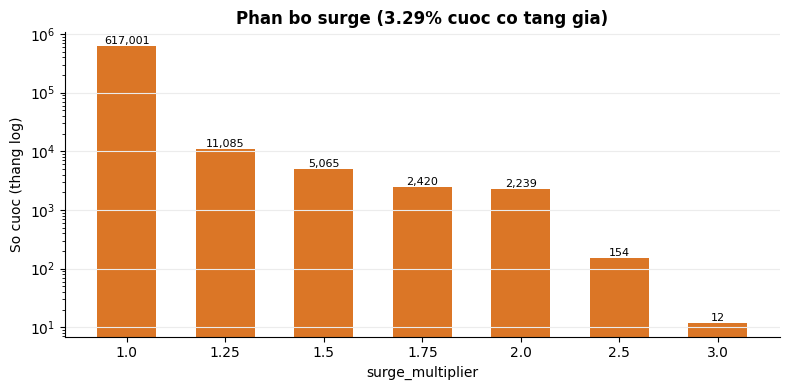

In [10]:
sv = df.surge_multiplier.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(sv.index.astype(str), sv.values, color=RED, alpha=.85, width=.6)
ax.set_yscale("log"); ax.set_ylabel("So cuoc (thang log)"); ax.set_xlabel("surge_multiplier")
ax.set_title(f"Phan bo surge ({df.is_surge.mean()*100:.2f}% cuoc co tang gia)", fontweight="bold")
ax.grid(axis="x", visible=False)
for i,(k,v) in enumerate(sv.items()): ax.text(i,v,f"{v:,}",ha="center",va="bottom",fontsize=8)
fig.tight_layout(); plt.show()

**7. Phân bố các trường**

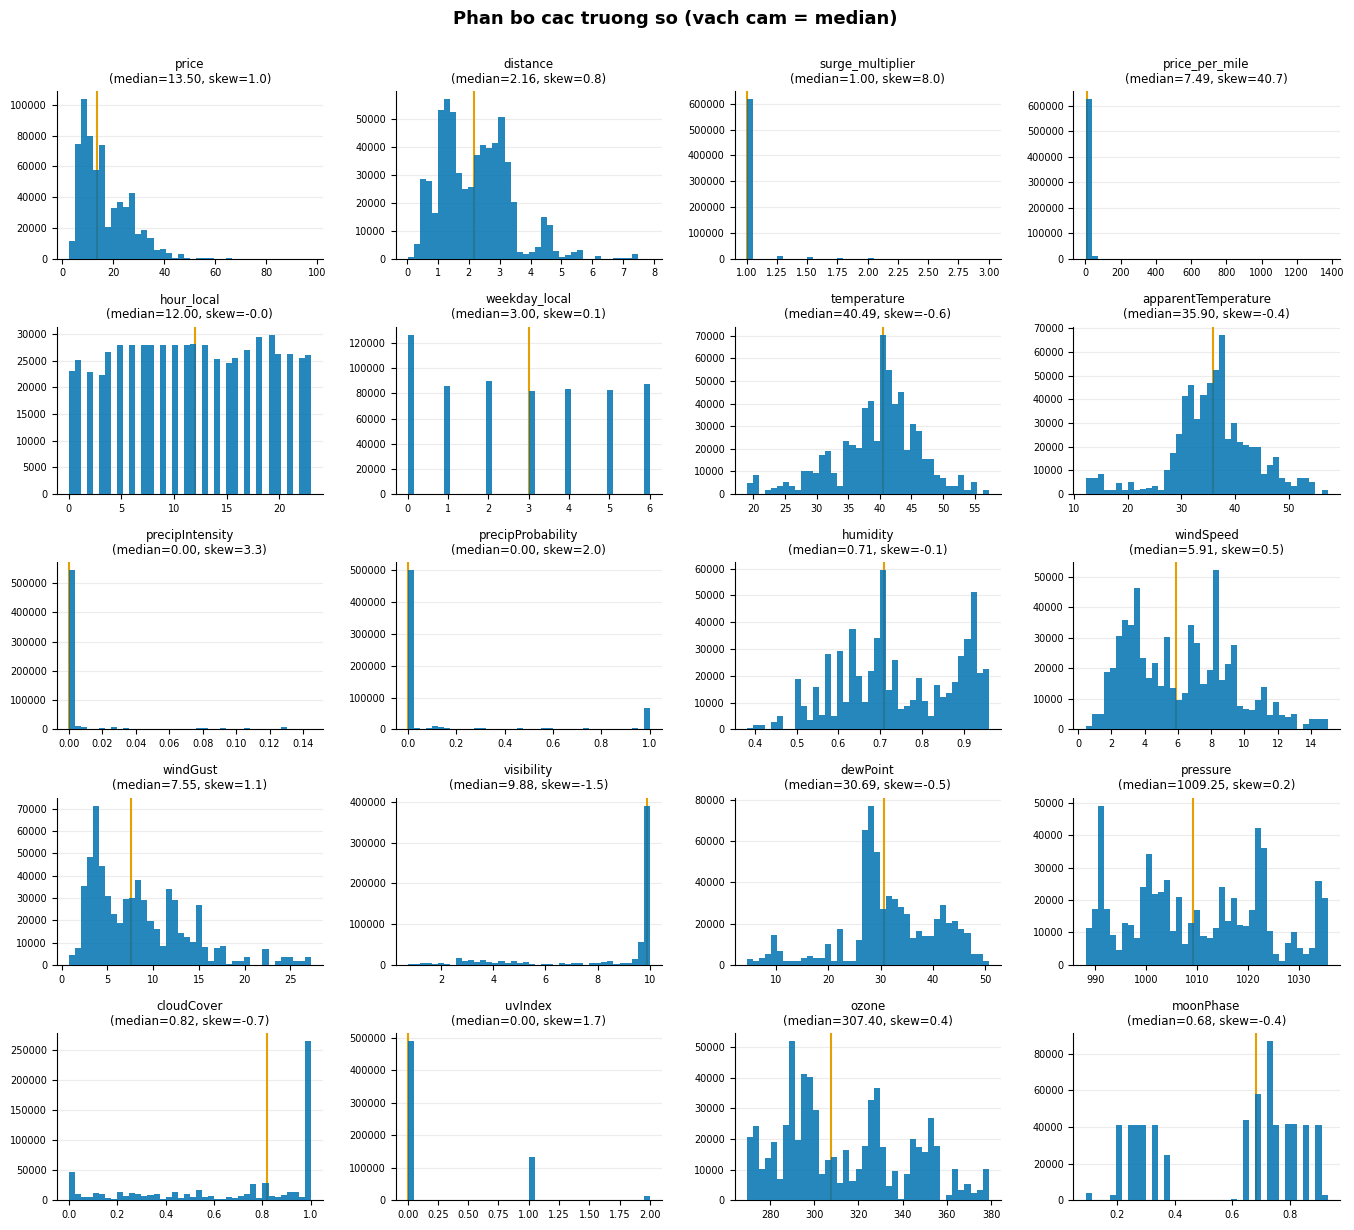

In [11]:
NUM = ["price","distance","surge_multiplier","price_per_mile","hour_local","weekday_local",
       "temperature","apparentTemperature","precipIntensity","precipProbability","humidity",
       "windSpeed","windGust","visibility","dewPoint","pressure","cloudCover","uvIndex","ozone","moonPhase"]
NUM = [c for c in NUM if c in df.columns]
ncols=4; nrows=math.ceil(len(NUM)/ncols)
fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*3.4,nrows*2.5))
axes=np.atleast_1d(axes).flatten()
for ax in axes[len(NUM):]: ax.axis("off")
for ax,c in zip(axes,NUM):
    x=df[c].dropna()
    ax.hist(x,bins=40,color=BLUE,alpha=.85,zorder=3)
    ax.axvline(x.median(),color=ORANGE,lw=1.5)
    ax.set_title(f"{c}\n(median={x.median():.2f}, skew={x.skew():.1f})",fontsize=8.5)
    ax.tick_params(labelsize=7); ax.grid(axis="x",visible=False)
fig.suptitle("Phan bo cac truong so (vach cam = median)",fontsize=13,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.98]); plt.show()

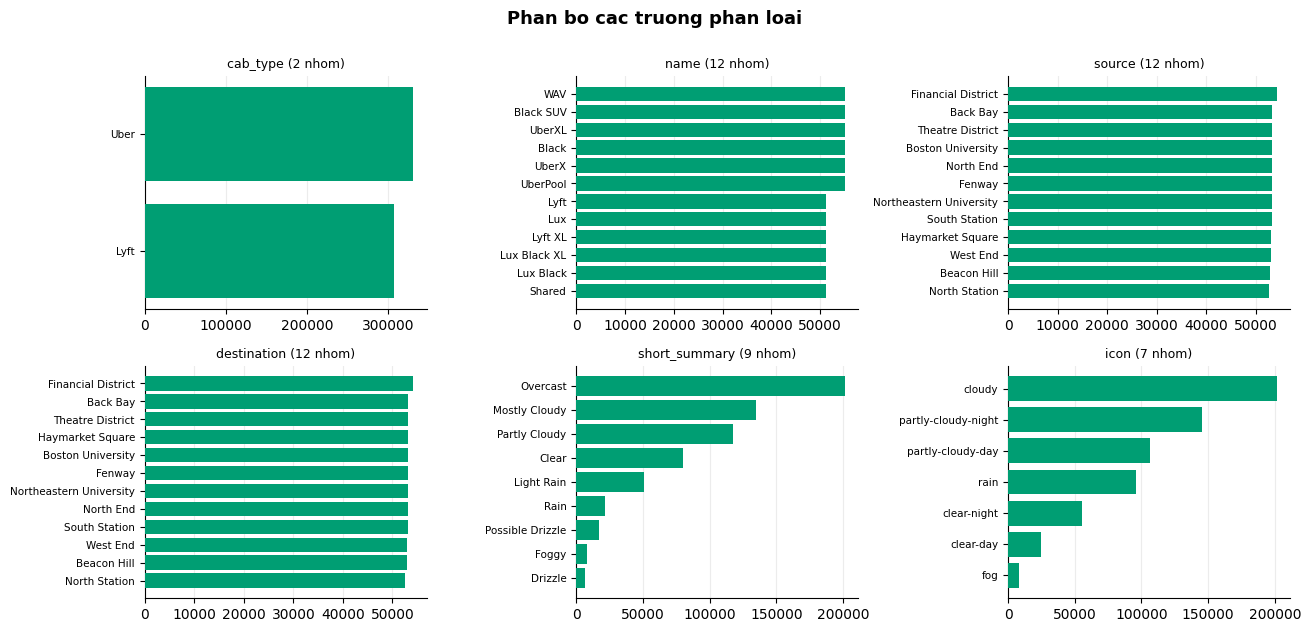

In [12]:
CAT=[c for c in ["cab_type","name","source","destination","short_summary","icon"] if c in df.columns]
ncols=3; nrows=math.ceil(len(CAT)/ncols)
fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*4.4,nrows*3.2))
axes=np.atleast_1d(axes).flatten()
for ax in axes[len(CAT):]: ax.axis("off")
for ax,c in zip(axes,CAT):
    vc=df[c].astype(str).value_counts().head(15)[::-1]
    ax.barh(range(len(vc)),vc.values,color=GREEN,zorder=3)
    ax.set_yticks(range(len(vc))); ax.set_yticklabels(vc.index,fontsize=7.5)
    ax.set_title(f"{c} ({df[c].nunique()} nhom)",fontsize=9); ax.grid(axis="y",visible=False)
fig.suptitle("Phan bo cac truong phan loai",fontsize=13,fontweight="bold")
fig.tight_layout(rect=[0,0,1,0.98]); plt.show()

**8. Tương quan giữa các trường**

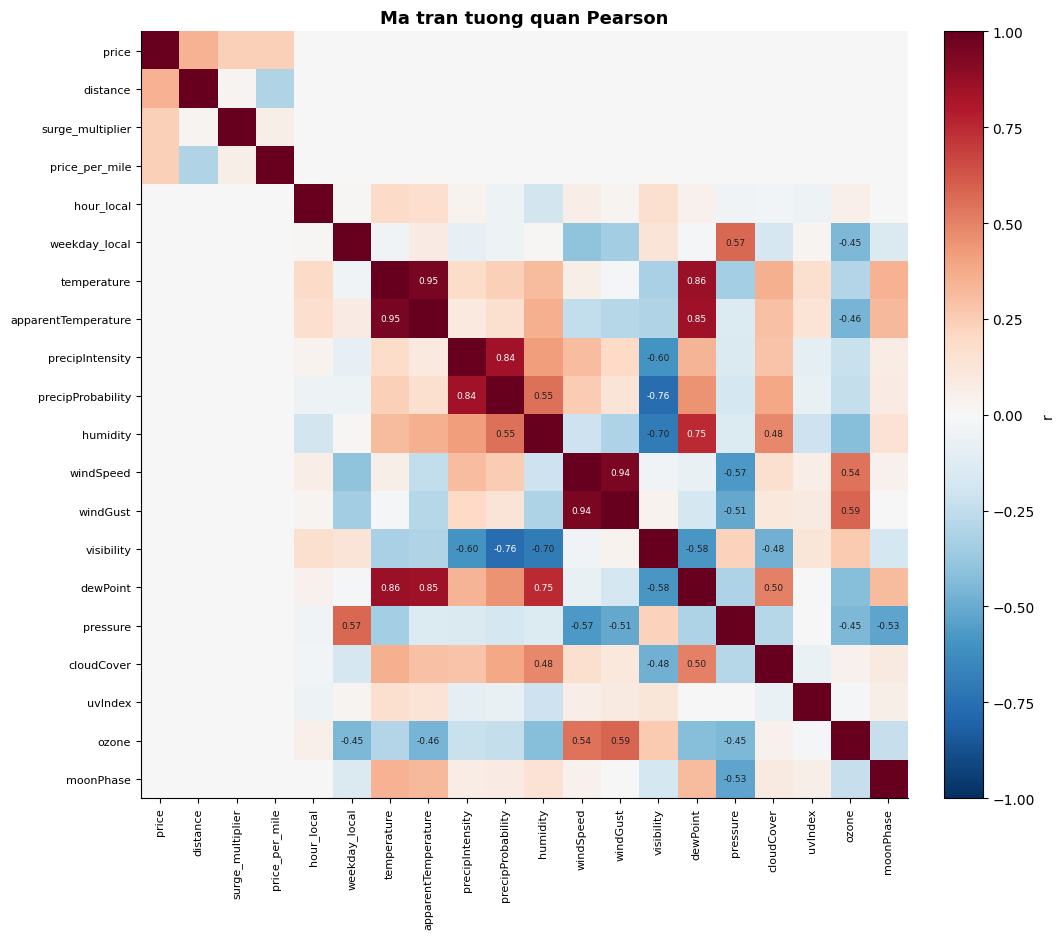

In [13]:
Cm=df[NUM].corr()
fig,ax=plt.subplots(figsize=(11,9.5))
im=ax.imshow(Cm,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM,rotation=90,fontsize=8)
ax.set_yticks(range(len(NUM))); ax.set_yticklabels(NUM,fontsize=8)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        v=Cm.iloc[i,j]
        if abs(v)>0.45 and i!=j:
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=6.5,
                    color="white" if abs(v)>0.7 else "#222")
ax.set_title("Ma tran tuong quan Pearson",fontsize=13,fontweight="bold")
fig.colorbar(im,fraction=0.046,pad=0.04).set_label("r"); ax.grid(False)
fig.tight_layout(); plt.show()

In [14]:
cm=df[NUM].corr().abs()
pairs=[(NUM[i],NUM[j],round(cm.iloc[i,j],3))
       for i in range(len(NUM)) for j in range(i+1,len(NUM)) if cm.iloc[i,j]>0.9]
print("Cap truong TRUNG LAP (|r| > 0.9) - nen giu 1 bo 1:")
pd.DataFrame(sorted(pairs,key=lambda x:-x[2]),columns=["Trường A","Trường B","|r|"])

Cap truong TRUNG LAP (|r| > 0.9) - nen giu 1 bo 1:


,Trường A,Trường B,|r|
0,temperature,apparentTemperature,0.946
1,windSpeed,windGust,0.938


**9. Độ phủ theo thời gian**

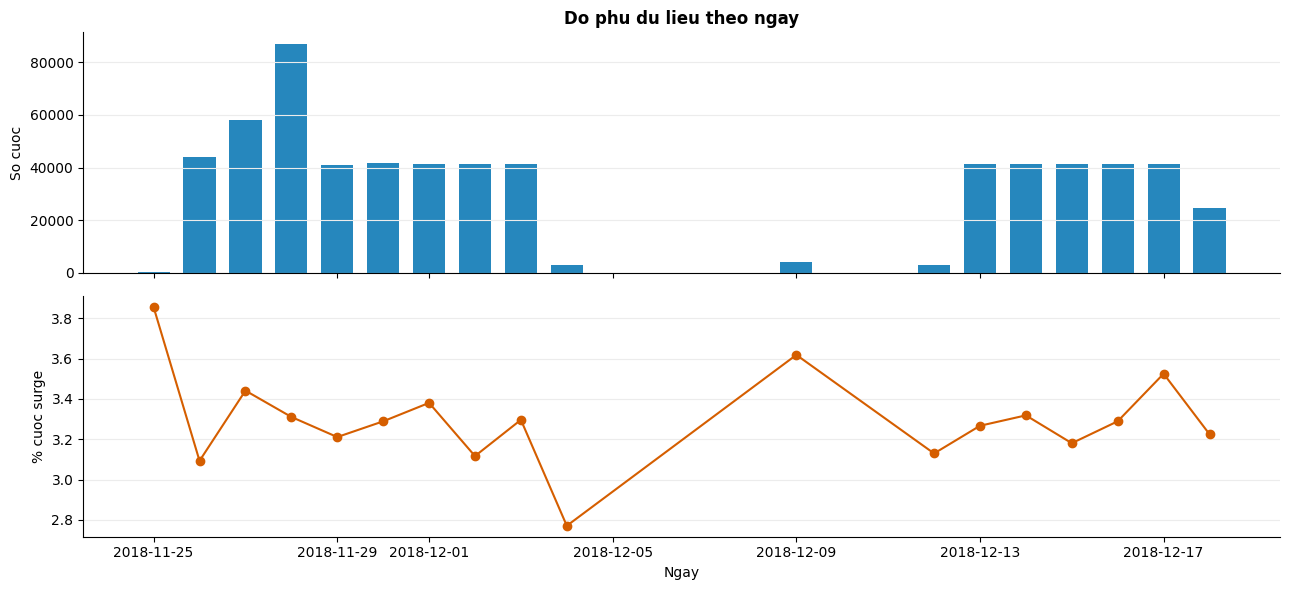

Khoang: 2018-11-25 -> 2018-12-18  (24 ngay lich, co du lieu 18 ngay)
Ngay THIEU: 2018-12-05, 2018-12-06, 2018-12-07, 2018-12-08, 2018-12-10, 2018-12-11


,date_local,so_cuoc,gia_TB,ty_le_surge
0,2018-11-25,467,16.892934,0.038544
1,2018-11-26,44071,16.529430,0.030927
2,2018-11-27,58242,16.601289,0.034408
3,2018-11-28,87029,16.535910,0.033104
4,2018-11-29,41051,16.546881,0.032106
5,2018-11-30,41811,16.428496,0.032886
6,2018-12-01,41389,16.594204,0.033801
7,2018-12-02,41298,16.509892,0.031164
8,2018-12-03,41201,16.519733,0.032960
9,2018-12-04,3140,16.508758,0.027707


In [15]:
daily=df.groupby("date_local").agg(so_cuoc=("price","size"),gia_TB=("price","mean"),
        ty_le_surge=("is_surge","mean")).reset_index()
fig,axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
axes[0].bar(daily.date_local,daily.so_cuoc,color=BLUE,alpha=.85,width=.7)
axes[0].set_ylabel("So cuoc"); axes[0].set_title("Do phu du lieu theo ngay",fontweight="bold")
axes[1].plot(daily.date_local,daily.ty_le_surge*100,marker="o",color=RED)
axes[1].set_ylabel("% cuoc surge"); axes[1].set_xlabel("Ngay")
for a in axes: a.grid(axis="x",visible=False)
fig.tight_layout(); plt.show()

full=pd.date_range(df.date_local.min(),df.date_local.max(),freq="D")
missing=sorted(set(full)-set(df.date_local.unique()))
print(f"Khoang: {df.date_local.min().date()} -> {df.date_local.max().date()}  "
      f"({len(full)} ngay lich, co du lieu {df.date_local.nunique()} ngay)")
if missing: print("Ngay THIEU:", ", ".join(str(d.date()) for d in missing))
daily

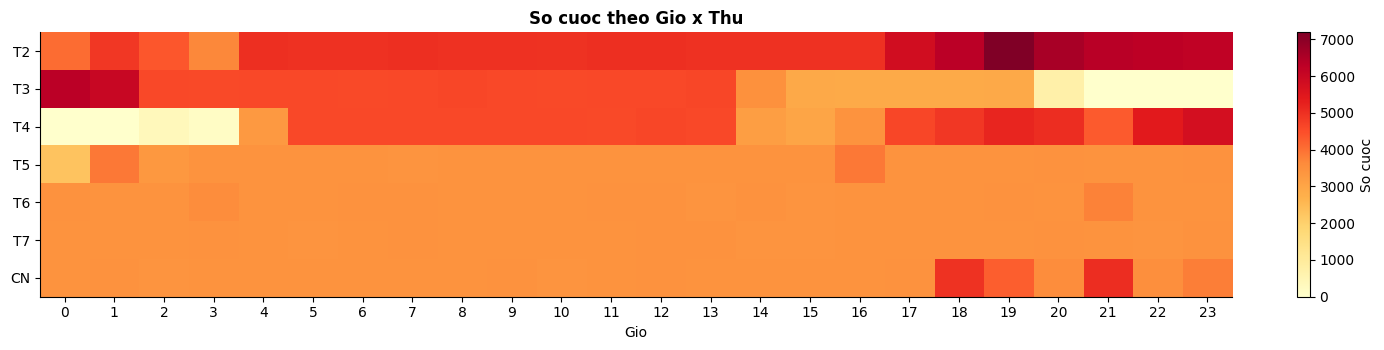

In [16]:
pv=df.pivot_table(index="weekday_local",columns="hour_local",values="price",aggfunc="size").fillna(0)
DAYS=["T2","T3","T4","T5","T6","T7","CN"]
fig,ax=plt.subplots(figsize=(14,3.6))
im=ax.imshow(pv,cmap="YlOrRd",aspect="auto")
ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns)
ax.set_yticks(range(len(pv))); ax.set_yticklabels([DAYS[i] for i in pv.index])
ax.set_xlabel("Gio"); ax.set_title("So cuoc theo Gio x Thu",fontweight="bold")
fig.colorbar(im,fraction=0.025).set_label("So cuoc"); ax.grid(False)
fig.tight_layout(); plt.show()

**10. Tổng kết**

In [17]:
print("="*64); print(f"TOM TAT — {CSV_PATH}"); print("="*64)
print(f"So chuyen        : {len(df):,}")
print(f"So truong        : {df.shape[1]}")
print(f"Khoang thoi gian : {df.date_local.min().date()} -> {df.date_local.max().date()} "
      f"({df.date_local.nunique()} ngay)")
print(f"Gia TB / median  : {df.price.mean():.2f} / {df.price.median():.2f} USD")
print(f"Quang duong TB   : {df.distance.mean():.2f} dam")
print(f"Ty le surge      : {df.is_surge.mean()*100:.2f}%  ({df.is_surge.sum():,} cuoc)")
for h in df.cab_type.unique():
    s=df[df.cab_type==h]
    print(f"   {h:<6}: {len(s):>7,} cuoc | surge {s.is_surge.mean()*100:5.2f}% "
          f"({s.is_surge.sum():,} cuoc)")

TOM TAT — ..\data\rideshare_kaggle.csv
So chuyen        : 637,976
So truong        : 64
Khoang thoi gian : 2018-11-25 -> 2018-12-18 (18 ngay)
Gia TB / median  : 16.55 / 13.50 USD
Quang duong TB   : 2.19 dam
Ty le surge      : 3.29%  (20,975 cuoc)
   Lyft  : 307,408 cuoc | surge  6.82% (20,975 cuoc)
   Uber  : 330,568 cuoc | surge  0.00% (0 cuoc)
